In [4]:
%load_ext ipympl
%matplotlib widget

# pip install casadi numpy
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
import imageio.v3 as iio

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

import ipywidgets as W


from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from matplotlib.patches import Wedge

import importlib, game_sharedutils, game_2dutils, game_3dutils, game_costs
importlib.reload(game_sharedutils)
importlib.reload(game_2dutils)
importlib.reload(game_3dutils)
importlib.reload(game_costs)


from game_sharedutils import dims_from_D
from game_2dutils    import solve_game_once_2d, plot_planned_trajectories_2d, run_rhc_and_collect_frames_2d
from game_3dutils    import solve_game_once_3d, plot_planned_trajectories_3d, run_rhc_and_collect_frames_3d, animate_rollout_3d,interactive_rollout_3d
from game_costs import build_costs


The ipympl module is not an IPython extension.


TypeError: bad operand type for unary -: 'list'

In [ ]:
# -----------------------------------------------------------------------------
# Config and notation
# -----------------------------------------------------------------------------
# State x = [px, py, vx, vy]ᵀ: position (px, py) and velocity (vx, vy)
# Control u = [ax, ay]ᵀ: acceleration inputs
# Horizon length T: number of state samples (there are T-1 control samples)
# Players: N=2 (player 1, player 2). Trajectories for each player i are packed into τᵢ.
# τ = [τ₁; τ₂]: concatenation of both players’ trajectories.
# θ (“theta”): parameter vector containing the stacked initial states for both players.
#
# We form a “variational inequality” style equilibrium by enforcing stationarity of each
# player’s Lagrangian w.r.t. its own τᵢ, plus shared dynamics/IC constraints g̃(τ,θ)=0
# and shared inequalities h̃(τ,θ) ≥ 0 (arena, bounds, separation, obstacles).
# -----------------------------------------------------------------------------


CONFIG = {
    # --- scenario / time ---
    "setting":  "chase_escape_tail",
    "D":        3,
    "T":        5,
    "dt":       0.1,
    "sim_time": 15.0,

    # --- dynamics ---
    "dynamics": "hcw",
    "hcw": {"mu": 3.986004418e14, "r0": 6_371_000.0 + 400_000.0},

    # --- initial states: [px,py,pz,vx,vy,vz] ---
    # (Initial speed defines initial boresight; keep vx,vy,vz nonzero if you care about direction)
    "x0": np.array([
        [ 2.0,  0.0, 0.0,  -0.02, 0.00, 0.000],
        [-2.0,  0.0, 0.0,   0.00, 0.00, -2.00],
    ], dtype=float),

    # --- workspace / constraints ---
    "arena": {"type": "sphere", "cx": 0.0, "cy": 0.0, "cz": 0.0, "r": 4.0},
    "vmax":   5.0,
    "umax":   10.0,
    "sep_min": 0.1,
    "spheres": [],  # optional keep-outs

    # --- field of view (use pinhole; cone values are legacy) ---
    "fov": {
        "enabled": True,
        "type": "pinhole",
        "agent": 1,                 # camera on agent 1 (change to 2 if needed)
        "color": "C1",
        "alpha": 0.15,
        "range": 3.0,               # legacy for cone; harmless here
        "hfov_deg": 60.0,           # legacy for cone; harmless here
        "min_speed_for_axis": 1e-3  # used as fallback threshold if att.* not set
    },

    # --- camera intrinsics / frustum (must match att['align']) ---
    "camera": {
        "W": 1280, "H": 720,
        "fx": 800.0, "fy": 800.0,
        "cx": 640.0, "cy": 360.0,
        "near": 0.05,
        "far":  1.5,
        "align": "x"                # match att['align'] (x-forward boresight)
    },

    # --- attitude (boresight from velocity; roll evolves via state) ---
    "att": {
    "mode": "quat",
    "J": [12.0, 10.0, 8.0],
    "tau_bounds": [-0.05, 0.05],  # per-axis symmetric or a scalar
    "w_bounds":   [-1.0, 1.0],
    "min_speed_for_axis": 1e-3,
    "align": "x", "up": [0,0,1],
    },


    "viz": {
        "triad_len": [0.6, 0.4, 0.4],
        "triad_colors": ["tab:red","tab:green","tab:blue"],
        "triad_labels": ["x_b (boresight)","y_b","z_b"],
    }
}



# Cool setting:

# CONFIG = {
#     # --- scenario / time ---
#     "setting":  "chase_escape_tail",
#     "D":        3,
#     "T":        10,
#     "dt":       0.1,
#     "sim_time": 45.0,

#     # --- dynamics (choose: "double" or "hcw") ---
#     "dynamics": "hcw",
#     "hcw": {  # compute n = sqrt(mu/r0^3)
#         "mu": 3.986004418e14,                 # m^3/s^2 (Earth)
#         "r0": 6_371_000.0 + 400_000.0,        # m (Earth radius + altitude)
#         # (you can instead pass "n": <rad/s> directly if you prefer)
#     },

#     # --- initial states: rows = agents, cols = [px,py,pz,vx,vy,vz] ---
#     "x0": np.array([
#         [ 1.0,  2.8, 0,  0.00, 0.00, -0.002],
#         [-1.0,  -2.8,  0,  0.00, 0.00, 0.002],
#     ], dtype=float),

#     # --- workspace / constraints ---
#     "arena": {"type": "sphere", "cx": 0.0, "cy": 0.0, "cz": 0.0, "r": 4.0},
#     "vmax":   5.0,
#     "umax":   10.0,
#     "sep_min": 0.1,

#     # optional 3D keep-out obstacles (must lie inside arena)
#     "spheres": [
#         # {"cx": 0.0, "cy": 0.0, "cz": 0.0, "r": 1.0},
#     ],

#     # --- field of view (used for visibility + drawing) ---
#     "fov": {
#         "enabled": True,
#         "type": "pinhole",          # <<< switch here
#         "agent": 1,                 # 2 means defender if that’s your convention
#         "color": "C1",
#         "alpha": 0.15,
#         # legacy (ignored when type='pinhole' except where you use them explicitly):
#         "range": 1.0,
#         "hfov_deg": 60.0,
#         "min_speed_for_axis": 1e-3
#     },

#     "camera": {
#         "W": 1280, "H": 720,
#         "fx": 800.0, "fy": 800.0,
#         "cx": 640.0, "cy": 360.0,
#         "near": 0.05,              # pick something > 0
#         "far":  1.0,               # you can mirror old fov["range"] here
#         "align": "x"               # <<< match att["align"]
#     },



#     # --- attitude (boresight aligned with velocity; roll about x̂_b) ---
#     "att": {
#         "mode": "hold",             # "hold" | "rate" | "track" (step_phi uses this)
#         "phi0": 0,#np.pi/2,                # initial roll angle [rad]
#         # For "rate" mode:   set "phi_rate": <rad/s>
#         # For "track" mode:  set "phi_target": <rad>, "tau": <s>
#         "align": "x",               # boresight is x̂ in body frame
#         "up": [0.0, 0.0, 1.0],      # world up used to construct triad
#         "min_speed_for_axis": 1e-3  # same logic as FOV; safe to keep duplicated here
#     },
# }





Saved 3D animation to traj_3D.gif


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 600) to (704, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved animation to traj_3D.mp4


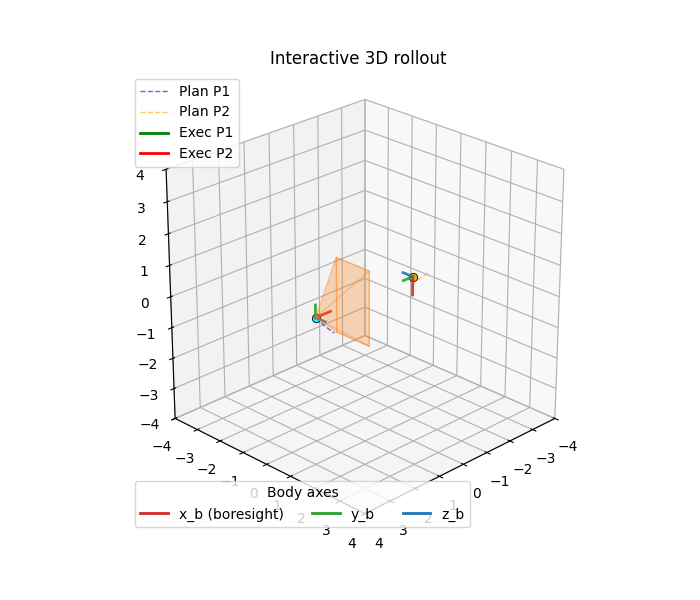

In [5]:
if __name__ == "__main__":
    # 1) Solve once & (optionally) plot
    #sol = solve_game_once_3d(cfg=CONFIG, cost_builder=build_costs)
    # plot_planned_trajectories_3d(sol, CONFIG)  # optional

    # 2) Generate rollout DATA
    rollout = run_rhc_and_collect_frames_3d(cfg=CONFIG, cost_builder=build_costs)

    # 3) Make a GIF or MP4 directly from the rollout (pick one)
    # GIF:
    animate_rollout_3d(rollout, save_path="traj_3D.gif", fps=20, cfg=CONFIG, show_fov=True, show_axes=True);

    # MP4 (preferred if ffmpeg is available):
    # animate_rollout_3d(rollout, save_path="traj_3D.mp4", fps=20, cfg=CONFIG, show_fov=True, show_axes=True)

    # If you really want to convert GIF -> MP4 via imageio (not necessary if using the MP4 line above):
    import imageio.v3 as iio
    gif_frames = iio.imread("traj_3D.gif")
    iio.imwrite("traj_3D.mp4", gif_frames, fps=20, codec="h264")
    print("Saved animation to traj_3D.mp4")

    # 4) INTERACTIVE viewer (Jupyter/Colab)
    interactive_rollout_3d(rollout, CONFIG, show_fov=True, show_axes=True)
